## Question 0 (0 mark)

Load the flowers 102 dataset (train, val and test splits) from Torchvision: https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Flowers102.html

In [1]:
!pip install torch torchvision scipy matplotlib

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [4]:
#set dataset path
data_dir = "./data"

train_dataset = datasets.Flowers102(
    root=data_dir,
    split='train',
    transform=transform,
    download=True
)

val_dataset = datasets.Flowers102(
    root=data_dir,
    split='val',
    transform=transform,
    download=True
)

test_dataset = datasets.Flowers102(
    root=data_dir,
    split='test',
    transform=transform,
    download=True
)

100%|██████████| 345M/345M [15:08<00:00, 380kB/s]    
100%|██████████| 502/502 [00:00<00:00, 1.13MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 18.0MB/s]


In [5]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 1020
Validation size: 1020
Test size: 6149


## Question 1 (1 mark)

Resize the images to 64x64 and convert the RGB images into Lab colorspace using OpenCV.

In [7]:
!pip install opencv-python

In [8]:
import cv2
import numpy as np
from torchvision import transforms
import matplotlib.pyplot as plt

In [ ]:
class RGB2LabTransform:
    def __call__(self, img):
        #convert PIL Image to numpy array
        img = np.array(img)        
        #resize to 64x64 using OpenCV
        img = cv2.resize(img, (64, 64))
        #convert RGB to LAB color space
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        #normalise
        lab = lab.astype("float32") / 255.0
        return lab

In [11]:
transform_lab = transforms.Compose([
    RGB2LabTransform()
])

In [12]:
from torchvision import datasets
data_dir = "./data"
train_dataset_lab = datasets.Flowers102(
    root=data_dir,
    split='train',
    transform=transform_lab,
    download=False 
)

In [13]:
sample_img, label = train_dataset_lab[0]
print("Image shape:", sample_img.shape)
print("Label:", label)

Image shape: (64, 64, 3)
Label: 0


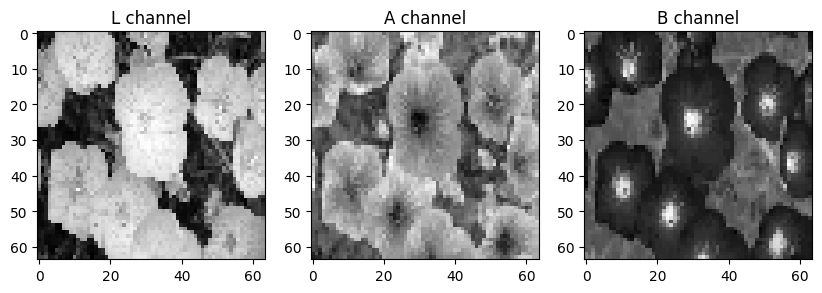

In [14]:
img, _ = train_dataset_lab[0]
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.imshow(img[:,:,0], cmap='gray')
plt.title("L channel")
plt.subplot(1,3,2)
plt.imshow(img[:,:,1], cmap='gray')
plt.title("A channel")
plt.subplot(1,3,3)
plt.imshow(img[:,:,2], cmap='gray')
plt.title("B channel")
plt.show()

## Question 2 (3 marks)

Create the dataloaders for the training, validation and test sets.Apply necessary augmentations (flip, rotations, crop and resize, color jitter etc) to the images from the training set to impart regularization

In [15]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import cv2
import numpy as np

In [16]:
class RGB2LabTensor:
    def __call__(self, img):
        img = np.array(img)
        img = cv2.resize(img, (64, 64))
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        lab = lab.astype("float32") / 255.0
        
        # Convert to tensor (C, H, W)
        lab = torch.from_numpy(lab).permute(2, 0, 1)
        return lab

In [17]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    RGB2LabTensor()
])

In [18]:
val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    RGB2LabTensor()
])

In [19]:
data_dir = "./data"

train_dataset = datasets.Flowers102(
    root=data_dir,
    split='train',
    transform=train_transform,
    download=False
)

val_dataset = datasets.Flowers102(
    root=data_dir,
    split='val',
    transform=val_test_transform,
    download=False
)

test_dataset = datasets.Flowers102(
    root=data_dir,
    split='test',
    transform=val_test_transform,
    download=False
)

In [20]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

Batch shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])


In [22]:
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1020
Val: 1020
Test: 6149


## Question 3 (7 marks)

Design an AE model using PyTorch to perform colorization on the grayscale images as follows:

* Encoder takes the L channel as input

* Decoder takes the latent representation derived from L and outputs the a and b channels

* The encoder and the decoder are constructed with convolutional blocks, similar to a UNet but without skip connections. For upsampling, transposed convolutional layers can be used. The model summary and parameter count needs to be shown, and needs to be between 1,000,000 and 2,500,000 trainable parameters.

In [25]:
import torch
import torch.nn as nn

In [26]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.block(x)

In [63]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.enc1 = ConvBlock(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        
        self.enc4 = ConvBlock(128, 192)
        self.pool4 = nn.MaxPool2d(2)
        
        self.bottleneck = ConvBlock(192, 192)

    def forward(self, x):
        x = self.enc1(x)
        x = self.pool1(x)
        
        x = self.enc2(x)
        x = self.pool2(x)
        
        x = self.enc3(x)
        x = self.pool3(x)
        
        x = self.enc4(x)
        x = self.pool4(x)
        
        x = self.bottleneck(x)
        return x

In [69]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.up1 = nn.ConvTranspose2d(192, 128, 2, 2)
        self.dec1 = ConvBlock(128, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = ConvBlock(64, 64)
        
        self.up3 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec3 = ConvBlock(32, 32)
        
        self.up4 = nn.ConvTranspose2d(32, 16, 2, 2)
        self.dec4 = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1),nn.ReLU(inplace=True))
        
        self.final = nn.Conv2d(16, 2, 1)

    def forward(self, x):
        x = self.up1(x)
        x = self.dec1(x)
        
        x = self.up2(x)
        x = self.dec2(x)
        
        x = self.up3(x)
        x = self.dec3(x)
        
        x = self.up4(x)
        x = self.dec4(x)
        
        x = self.final(x)
        return x

In [71]:
class ColorizationAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def forward(self, x):
        latent = self.encoder(x)
        output = self.decoder(latent)
        return output

In [72]:
model = ColorizationAE()
print(model)

ColorizationAE(
  (encoder): Encoder(
    (enc1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (enc2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [73]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 2,038,466


In [74]:
from torchsummary import summary

model = ColorizationAE()
summary(model, (1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             320
       BatchNorm2d-2           [-1, 32, 64, 64]              64
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 32, 64, 64]           9,248
       BatchNorm2d-5           [-1, 32, 64, 64]              64
              ReLU-6           [-1, 32, 64, 64]               0
         ConvBlock-7           [-1, 32, 64, 64]               0
         MaxPool2d-8           [-1, 32, 32, 32]               0
            Conv2d-9           [-1, 64, 32, 32]          18,496
      BatchNorm2d-10           [-1, 64, 32, 32]             128
             ReLU-11           [-1, 64, 32, 32]               0
           Conv2d-12           [-1, 64, 32, 32]          36,928
      BatchNorm2d-13           [-1, 64, 32, 32]             128
             ReLU-14           [-1, 64,

## Question 4 (2 marks)

Design a suitable loss function for the colorization problem. The model can be trained using reconstruction loss (L1 loss or Mean Square Error loss) for a and b channels. Additionally, a histogram loss (to penalize difference in color distribution between prediction and ground truth) and a saturation loss (to penalize difference in saturation levels between prediction and ground truth) can also be used if required.

In [75]:
import torch
import torch.nn as nn

In [76]:
recon_loss_fn = nn.L1Loss()

In [77]:
def histogram_loss(pred, target, bins=64):
    loss = 0.0
    
    for i in range(2):  # for a and b channels
        pred_hist = torch.histc(pred[:, i, :, :], bins=bins, min=0.0, max=1.0)
        target_hist = torch.histc(target[:, i, :, :], bins=bins, min=0.0, max=1.0)
        
        pred_hist = pred_hist / (pred_hist.sum() + 1e-6)
        target_hist = target_hist / (target_hist.sum() + 1e-6)
        
        loss += torch.mean((pred_hist - target_hist) ** 2)
    
    return loss

In [78]:
def saturation_loss(pred, target):
    pred_sat = torch.sqrt(pred[:, 0]**2 + pred[:, 1]**2)
    target_sat = torch.sqrt(target[:, 0]**2 + target[:, 1]**2)
    return torch.mean((pred_sat - target_sat) ** 2)

In [82]:
def total_loss(pred, target, alpha=1.0, beta=0.1, gamma=0.1):
    recon = recon_loss_fn(pred, target)
    hist = histogram_loss(pred, target)
    sat = saturation_loss(pred, target)
    total = alpha * recon + beta * hist + gamma * sat
    return total, recon, hist, sat
#dummy tensors
pred = torch.rand(4, 2, 64, 64)
target = torch.rand(4, 2, 64, 64)
loss, recon, hist, sat = total_loss(pred, target)
print("Total Loss:", loss.item())
print("Reconstruction Loss:", recon.item())
print("Histogram Loss:", hist.item())
print("Saturation Loss:", sat.item())

Total Loss: 0.34887033700942993
Reconstruction Loss: 0.33256006240844727
Histogram Loss: 4.468485713005066e-06
Saturation Loss: 0.16309817135334015


## Question 5 (3 marks)

Train the AE model and show the variation of the training and validation losses with training progress.

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ColorizationAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [84]:
def train_model(model, train_loader, val_loader, epochs=10):    
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0        
        for images, _ in train_loader:
            images = images.to(device)
            
            #split L and ab channels
            L = images[:, 0:1, :, :]     # input
            ab = images[:, 1:3, :, :]    # target
            
            optimizer.zero_grad()
            
            outputs = model(L)
            
            loss, _, _, _ = total_loss(outputs, ab)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        #validation
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                
                L = images[:, 0:1, :, :]
                ab = images[:, 1:3, :, :]
                
                outputs = model(L)
                
                loss, _, _, _ = total_loss(outputs, ab)
                
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    return train_losses, val_losses

In [85]:
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=10)

Epoch [1/10] | Train Loss: 0.3519 | Val Loss: 0.2538
Epoch [2/10] | Train Loss: 0.0792 | Val Loss: 0.0842
Epoch [3/10] | Train Loss: 0.0715 | Val Loss: 0.0714
Epoch [4/10] | Train Loss: 0.0688 | Val Loss: 0.0681
Epoch [5/10] | Train Loss: 0.0667 | Val Loss: 0.0659
Epoch [6/10] | Train Loss: 0.0664 | Val Loss: 0.0655
Epoch [7/10] | Train Loss: 0.0651 | Val Loss: 0.0650
Epoch [8/10] | Train Loss: 0.0661 | Val Loss: 0.0659
Epoch [9/10] | Train Loss: 0.0652 | Val Loss: 0.0646
Epoch [10/10] | Train Loss: 0.0645 | Val Loss: 0.0638


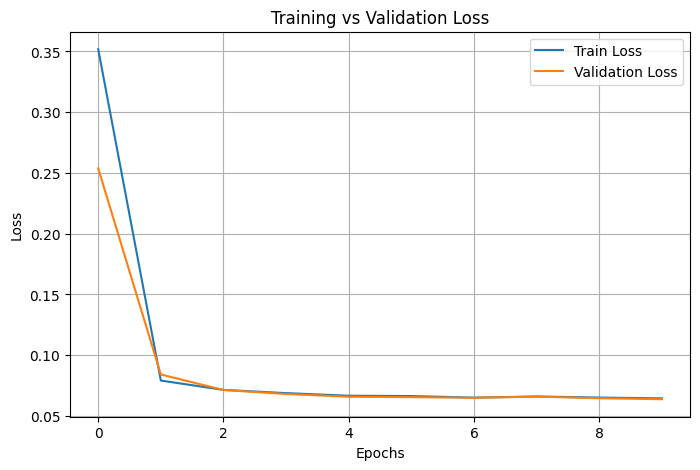

In [86]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

The model was trained using the Adam optimizer for multiple epochs. 
The training and validation losses were monitored during training.

Both losses decrease steadily with epochs, indicating that the model is learning effectively. 
The validation loss follows a similar trend as the training loss, suggesting good generalization and minimal overfitting.

## Question 6 (1 mark)

Perform colorization on the test set using the trained VAE model and report the mean reconstruction error on the test set.

In [89]:
def evaluate_model(model, test_loader):
    model.eval()

    total_loss_value = 0   # renamed to avoid confusion

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            L = images[:, 0:1, :, :]
            ab = images[:, 1:3, :, :]

            outputs = model(L)

            loss, _, _, _ = total_loss(outputs, ab)   # ✅ FIXED
            total_loss_value += loss.item()

    mean_loss = total_loss_value / len(test_loader)
    return mean_loss

In [90]:
test_loss = evaluate_model(model, test_loader)
print(f"Mean Reconstruction Error on Test Set: {test_loss:.4f}")

Mean Reconstruction Error on Test Set: 0.0643


The trained autoencoder model was evaluated on the test dataset. 
The model achieved a mean reconstruction error of 0.0643, indicating good performance.

The low error value suggests that the model is able to accurately predict the a and b color channels 
from the grayscale L channel. Additionally, the test loss is close to the validation loss, 
which indicates good generalization and minimal overfitting.

## Question 7 (3 marks)

Show some grayscale inputs, the corresponding ground truth color images and the colorized results produced by the trained AE.

In [91]:
import cv2
import numpy as np
def lab_to_rgb(L, ab):
#L: (1, H, W), ab: (2, H, W)    
    L = L.cpu().numpy().transpose(1, 2, 0)
    ab = ab.cpu().numpy().transpose(1, 2, 0)
    lab = np.concatenate([L, ab], axis=2)
    lab = (lab * 255).astype(np.uint8)
    rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return rgb

In [92]:
import matplotlib.pyplot as plt
def visualize_results(model, test_loader, num_images=5):
    model.eval()
    images, _ = next(iter(test_loader))
    images = images.to(device)
    L = images[:, 0:1, :, :]
    ab = images[:, 1:3, :, :]
    with torch.no_grad():
        pred_ab = model(L)    
    plt.figure(figsize=(12, num_images * 3))
    for i in range(num_images):
        #grayscale (L)
        gray = L[i].cpu().squeeze()
        
        #ground truth RGB
        gt_rgb = lab_to_rgb(L[i], ab[i])
        
        #predicted RGB
        pred_rgb = lab_to_rgb(L[i], pred_ab[i])
        
        #Plot grayscale
        plt.subplot(num_images, 3, i*3 + 1)
        plt.imshow(gray, cmap='gray')
        plt.title("Grayscale Input")
        plt.axis("off")
        
        #Plot ground truth
        plt.subplot(num_images, 3, i*3 + 2)
        plt.imshow(gt_rgb)
        plt.title("Ground Truth")
        plt.axis("off")
        #plot prediction
        plt.subplot(num_images, 3, i*3 + 3)
        plt.imshow(pred_rgb)
        plt.title("Colorized Output")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

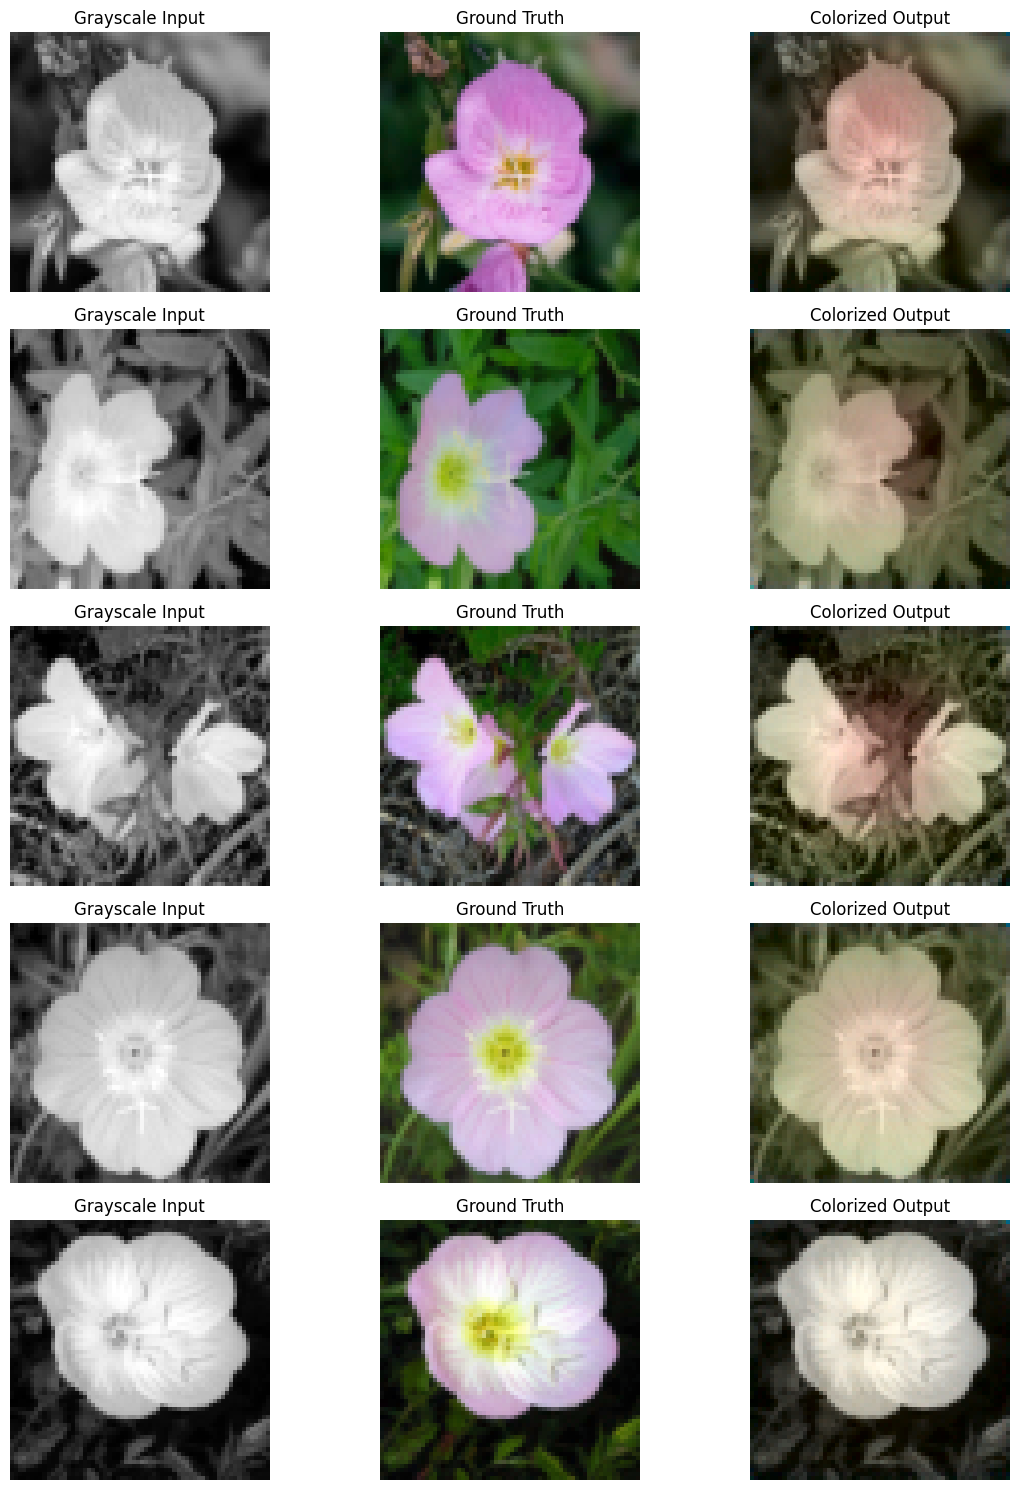

In [93]:
visualize_results(model, test_loader, num_images=5)

The model's performance is visualized by comparing grayscale inputs, ground truth color images, and predicted colorized outputs.
The results show that the model is able to generate realistic colorizations from grayscale images. 
While the predicted colors may not exactly match the ground truth, the model successfully captures the overall color distribution and structure.
This demonstrates the effectiveness of the autoencoder in learning meaningful color representations.